In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [4]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [5]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [6]:
rate_col = "CNS Rate"

In [7]:
design_matrix_otrain[rate_col].mean()

0.28874999999999995

In [8]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

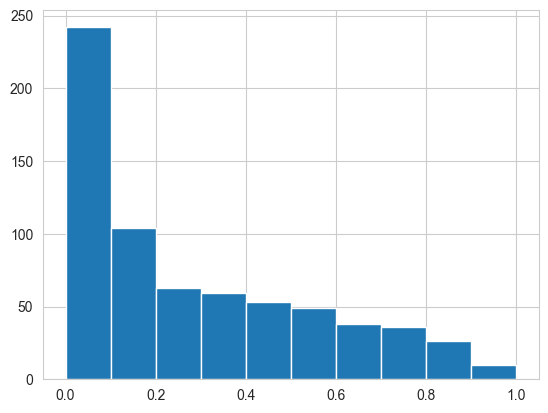

In [9]:
design_matrix_train[rate_col].hist(bins=10)

In [10]:
design_matrix_train['group'].value_counts()

group
1    407
2    273
Name: count, dtype: int64

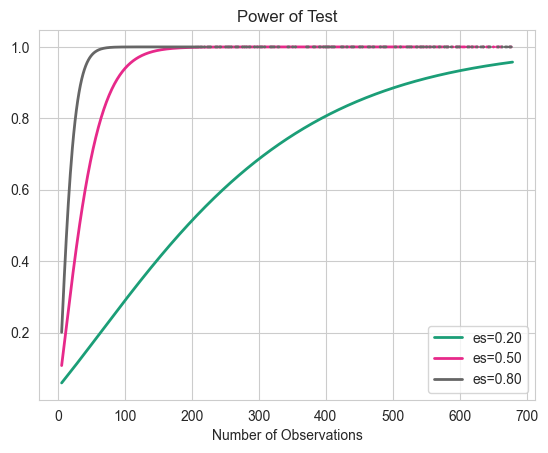

In [11]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [12]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [13]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [14]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [15]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

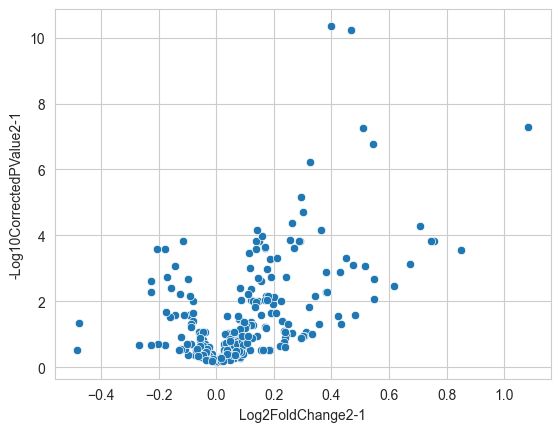

In [16]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [17]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
230,P01034,CYTC_HUMAN,1.065402,12.393145,11.995284,0.730100,0.641275,0.397862,2.208009e-13,273,...,12.388361,11.367966,11.808035,12.448976,11.842510,12.033297,11.763599,12.130882,11.829693,11.762052
123,P61769,B2MG_HUMAN,1.058048,12.245204,11.778012,0.898975,0.747877,0.467192,5.942635e-13,273,...,12.652368,10.490738,11.618301,12.289228,11.372313,11.781104,10.906047,11.750655,11.657643,12.220980
276,Q9Y279,VSIG4_HUMAN,1.232088,7.039902,5.957384,2.250882,2.190303,1.082518,7.777571e-10,273,...,8.632800,3.843913,3.922370,8.381036,3.828391,8.040848,4.412084,8.752571,6.987103,8.367238
154,P01033,TIMP1_HUMAN,0.850090,10.634404,10.126347,1.137346,0.984233,0.508057,1.070431e-09,273,...,11.305144,9.690175,10.005689,11.112195,9.291888,10.080163,9.175368,10.305271,10.987082,9.923244
107,P18065,IBP2_HUMAN,0.831714,10.478177,9.932983,1.059591,1.236595,0.545194,4.198609e-09,273,...,11.233598,4.060034,10.352136,11.525362,9.643937,10.984311,9.458948,10.260785,11.075334,10.068544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,P05106,ITB3_HUMAN,0.010294,7.285853,7.296823,2.166795,2.182779,-0.010971,9.487189e-01,273,...,8.396538,8.474307,8.696033,10.858330,8.432142,8.781202,8.341675,3.675169,3.406400,8.641600
14,P19827,ITIH1_HUMAN,0.002375,15.800513,15.798700,0.422141,0.358106,0.001813,9.520996e-01,273,...,16.005433,16.369418,15.973812,15.852236,15.930866,15.948744,16.182520,15.609745,16.140612,15.570671
26,P35542,SAA4_HUMAN,0.002397,15.604355,15.602299,0.502573,0.500419,0.002056,9.582689e-01,273,...,15.990683,16.530379,14.785601,16.381545,15.346850,16.376111,15.979202,15.981694,16.149647,14.644432
151,Q13790,APOF_HUMAN,0.001915,12.196399,12.198103,0.515094,0.578034,-0.001703,9.686850e-01,273,...,12.550076,11.469266,12.664111,11.759068,11.788256,12.583688,11.011265,12.287558,10.980568,12.105173


In [18]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [19]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [20]:
protein_columns = training_data.columns.to_list()

In [21]:
len(protein_columns)

287

In [22]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.6886446886446885,
 0.6763817761086454,
 0.7426740997751874,
 0.7337377401102891,
 0.8326915096522939)

In [25]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [26]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [27]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
PHLD_HUMAN,0.947498,0.612027,0.761072,0.773532
ACTN4_HUMAN,0.843307,0.527057,0.858674,0.743013
TETN_HUMAN,0.640060,0.762620,0.727930,0.710204
ENOA_HUMAN,0.652043,0.571254,0.824006,0.682435
CO8G_HUMAN,0.732404,0.545141,0.769157,0.682234
...,...,...,...,...
FCG3A_HUMAN,0.061874,0.009043,0.055778,0.042232
APOH_HUMAN,0.011203,0.055858,0.046959,0.038007
PRG2_HUMAN,0.021118,0.031998,0.046249,0.033122


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

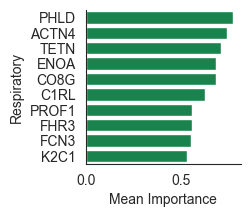

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "CNS"

In [34]:
feature_importance_results.to_csv(
    "cns_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/cns_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/cns_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
